### PI NADYA PUTRI NUR ALETTA (51423061)
### DETEKSI PENYAKIT DAUN MENTIMUN MENGGUNAKAN MODEL YOLO26m

In [1]:
import torch
print(torch.__version__)

2.11.0+cu128


In [1]:
import psutil
import platform
import torch
import subprocess

print("=== CPU ===")
subprocess.run(["lscpu"])

print("\n=== RAM ===")
print(f"{psutil.virtual_memory().total / (1024**3):.2f} GB")

print("\n=== GPU ===")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/(1024**3):.2f} GB")
else:
    print("GPU tidak tersedia")

=== CPU ===

=== RAM ===
12.67 GB

=== GPU ===
Tesla T4
VRAM: 14.56 GB


#### BAGIAN 1: Verifikasi GPU dan Install Dependencies

In [ ]:
# 1. Cek apakah GPU NVIDIA sudah aktif
!nvidia-smi

Sat Jun 27 02:29:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# 2. Install library Ultralytics untuk eksekusi YOLO dan Roboflow untuk mengambil data
!pip install ultralytics roboflow

#### BAGIAN 2: Mengunduh Dataset dari Roboflow

In [ ]:
from roboflow import Roboflow

# Snippet atau API kode dari Roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="Zm4bvMlEwsmRWr0VU3O6")
project = rf.workspace("aletta-workspace").project("pi_cucumber_leaf_disease-3")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pi_cucumber_leaf_disease-3-1 in yolo26:: 100%|██████████| 2315/2315 [00:00<00:00, 3306.77it/s]


#### BAGIAN 3: Menghubungkan Google Colab dengan Drive untuk Menyimpan Model Terbaik Saat Training

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### BAGIAN 4: Inisialisasi Arsitektur dan Mulai Training YOLO26m

In [ ]:
import os
from ultralytics import YOLO

# 1. Inisialisasi model YOLO26m
model = YOLO('yolo26m.pt')

# 2. Jalur folder penyimpanan di Google Drive
save_directory = '/content/drive/MyDrive/PI (PENULISAN ILMIAH SEMESTER 6) 2026/BEST MODEL YOLO26n-v3'
os.makedirs(save_directory, exist_ok=True)

# 3. Mulai proses training dengan Early Stopping dan GDrive
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=200,            # Naikkan jadi 200 (karena model lebih besar butuh lebih lama belajar)
    imgsz=640,
    batch=16,
    device=0,
    patience=50,           # Early stopping aktif (patience 50 epoch)
    mosaic=1.0,            # Pastikan mosaic aktif (default 1.0)
    mixup=0.2,             # Tambahkan mixup (mencampur 2 gambar menjadi 1)
    degrees=15.0,          # Rotasi daun
    flipud=0.5,             # Flip vertikal
    lr0=0.001,
    project=save_directory,   # Otomatis tersimpan ke folder BEST MODEL YOLO26n-v3 di GDrive
    name='v2_training'        # Hasil training akan tersimpan di dalam folder 'v2_training'
)

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pi_cucumber_leaf_disease-3-1/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v2_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

#### BAGIAN 5: Evaluasi Performa Model (Visualisasi Metrik) Dengan YOLO26m

--- MENAMPILKAN HASIL EVALUASI MODEL ---

[1] Confusion Matrix:


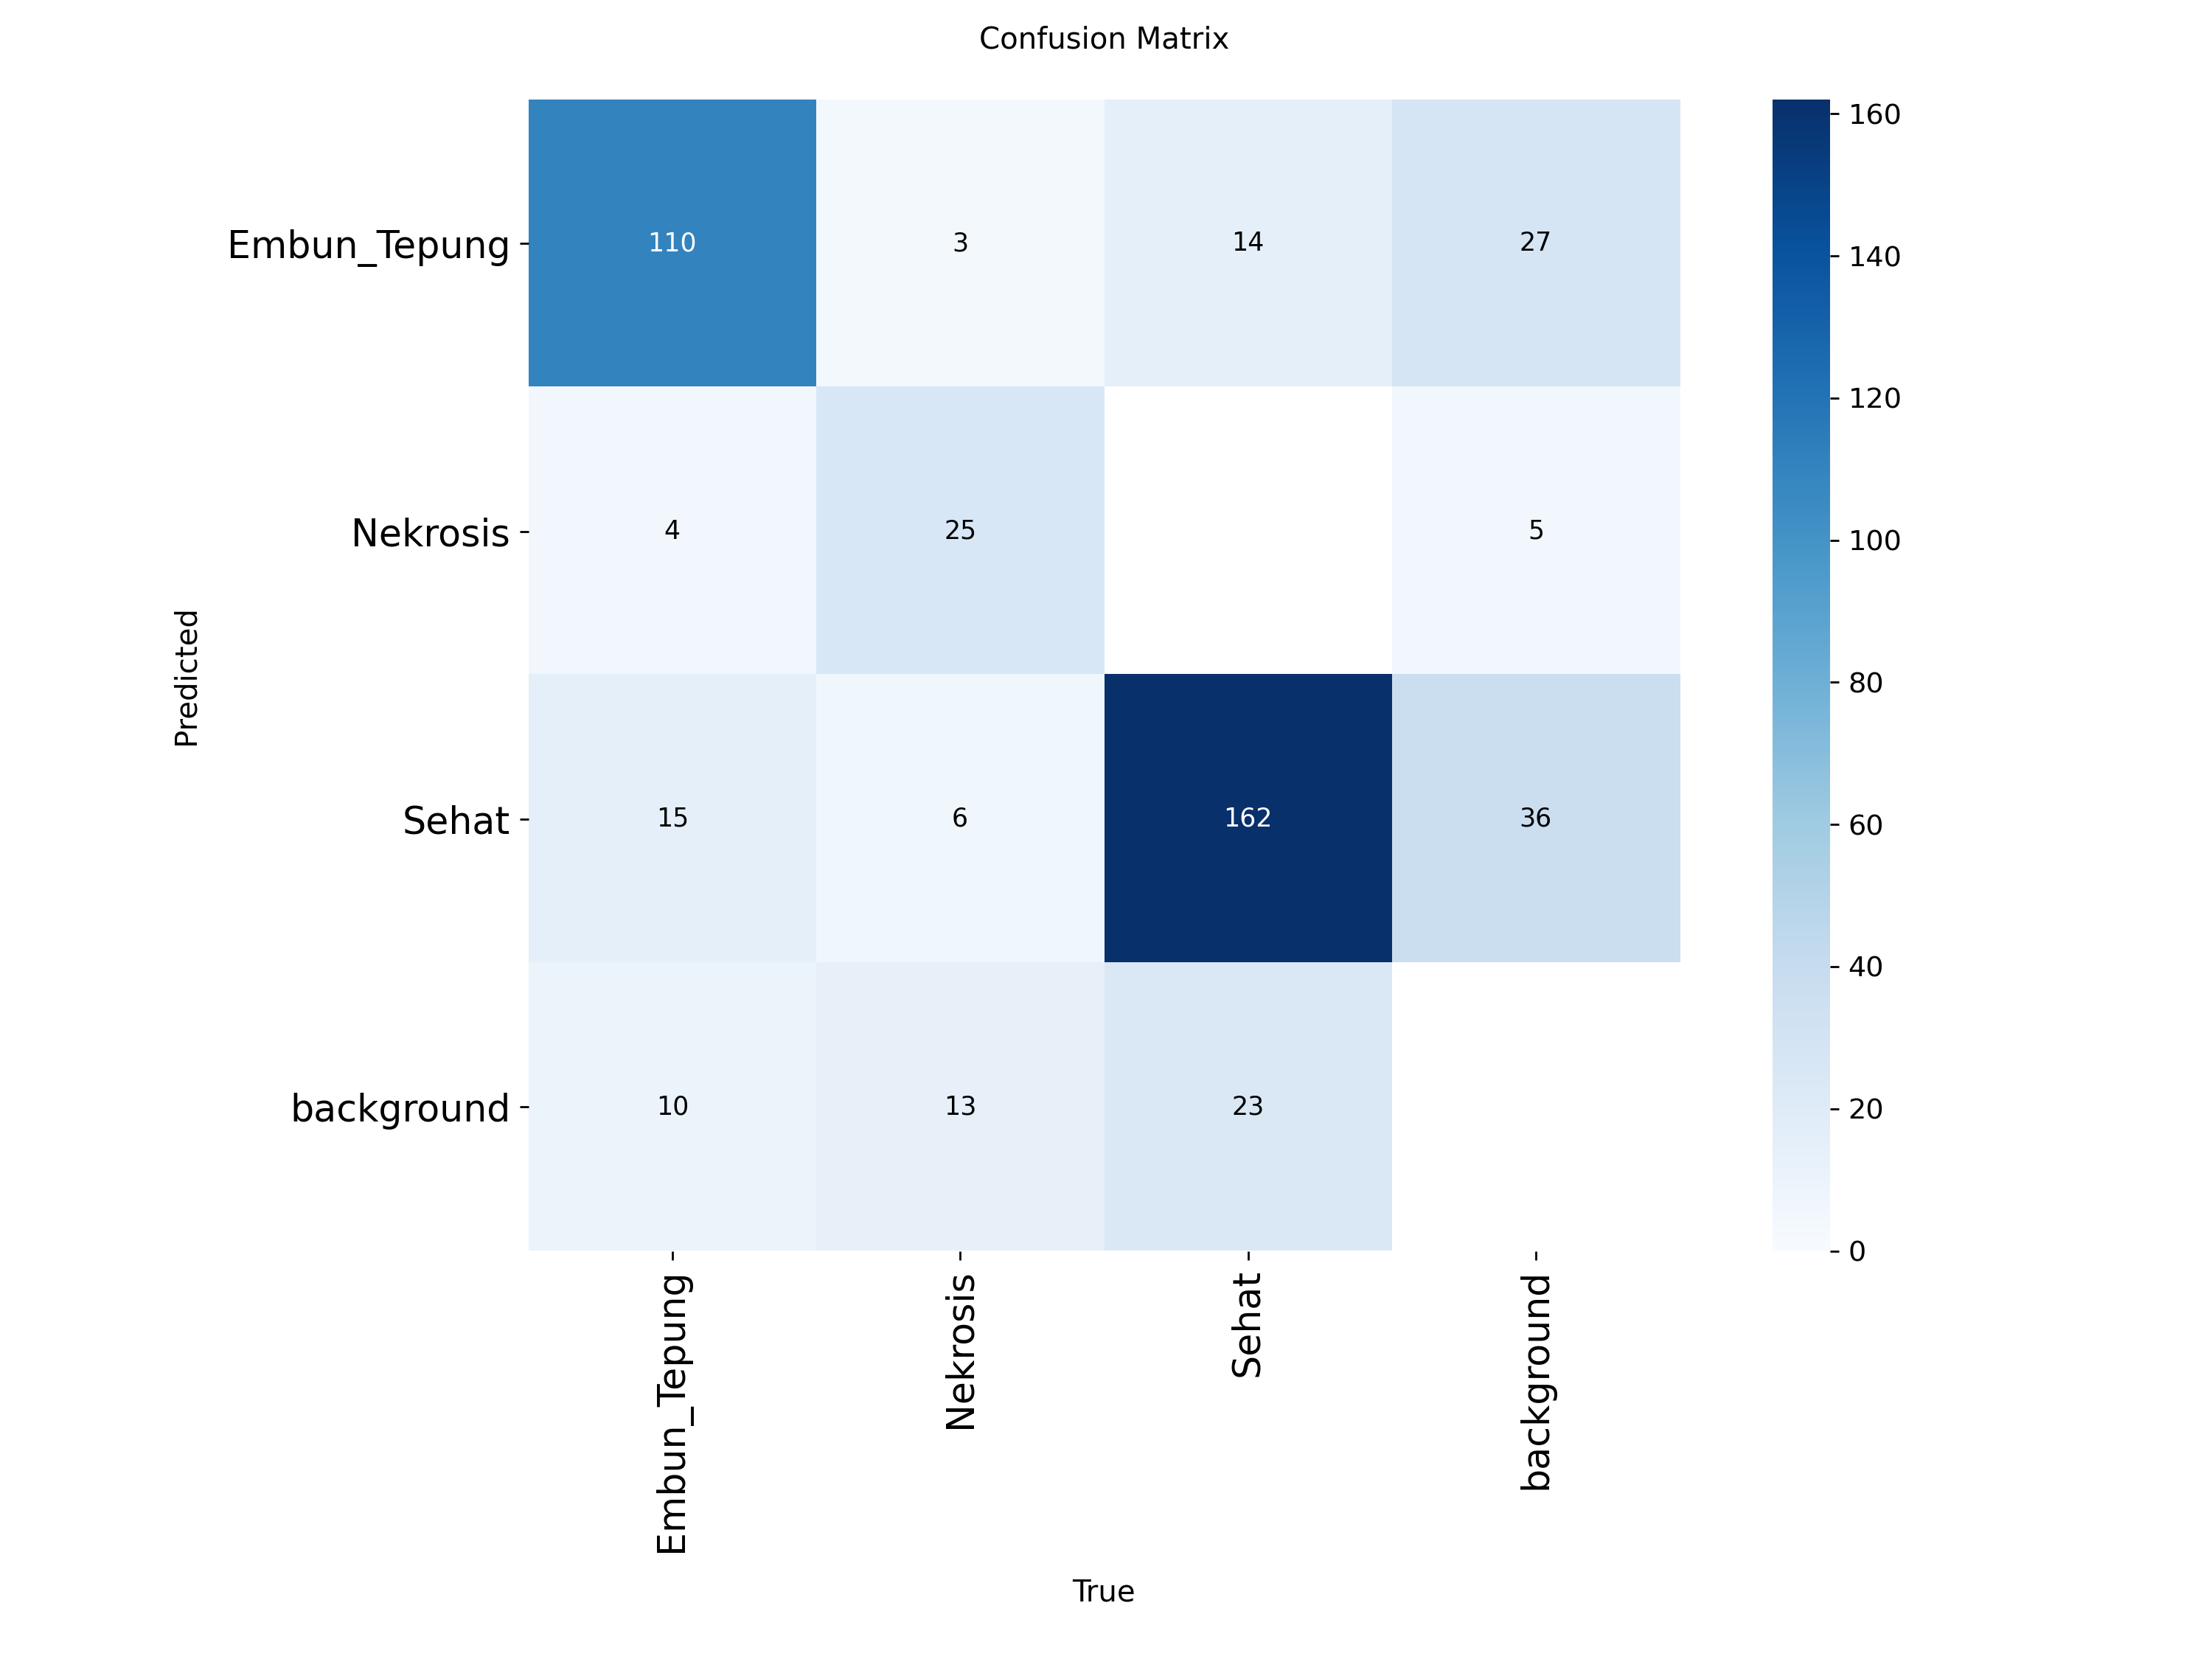


[2] Grafik Perkembangan Training (Loss & mAP):


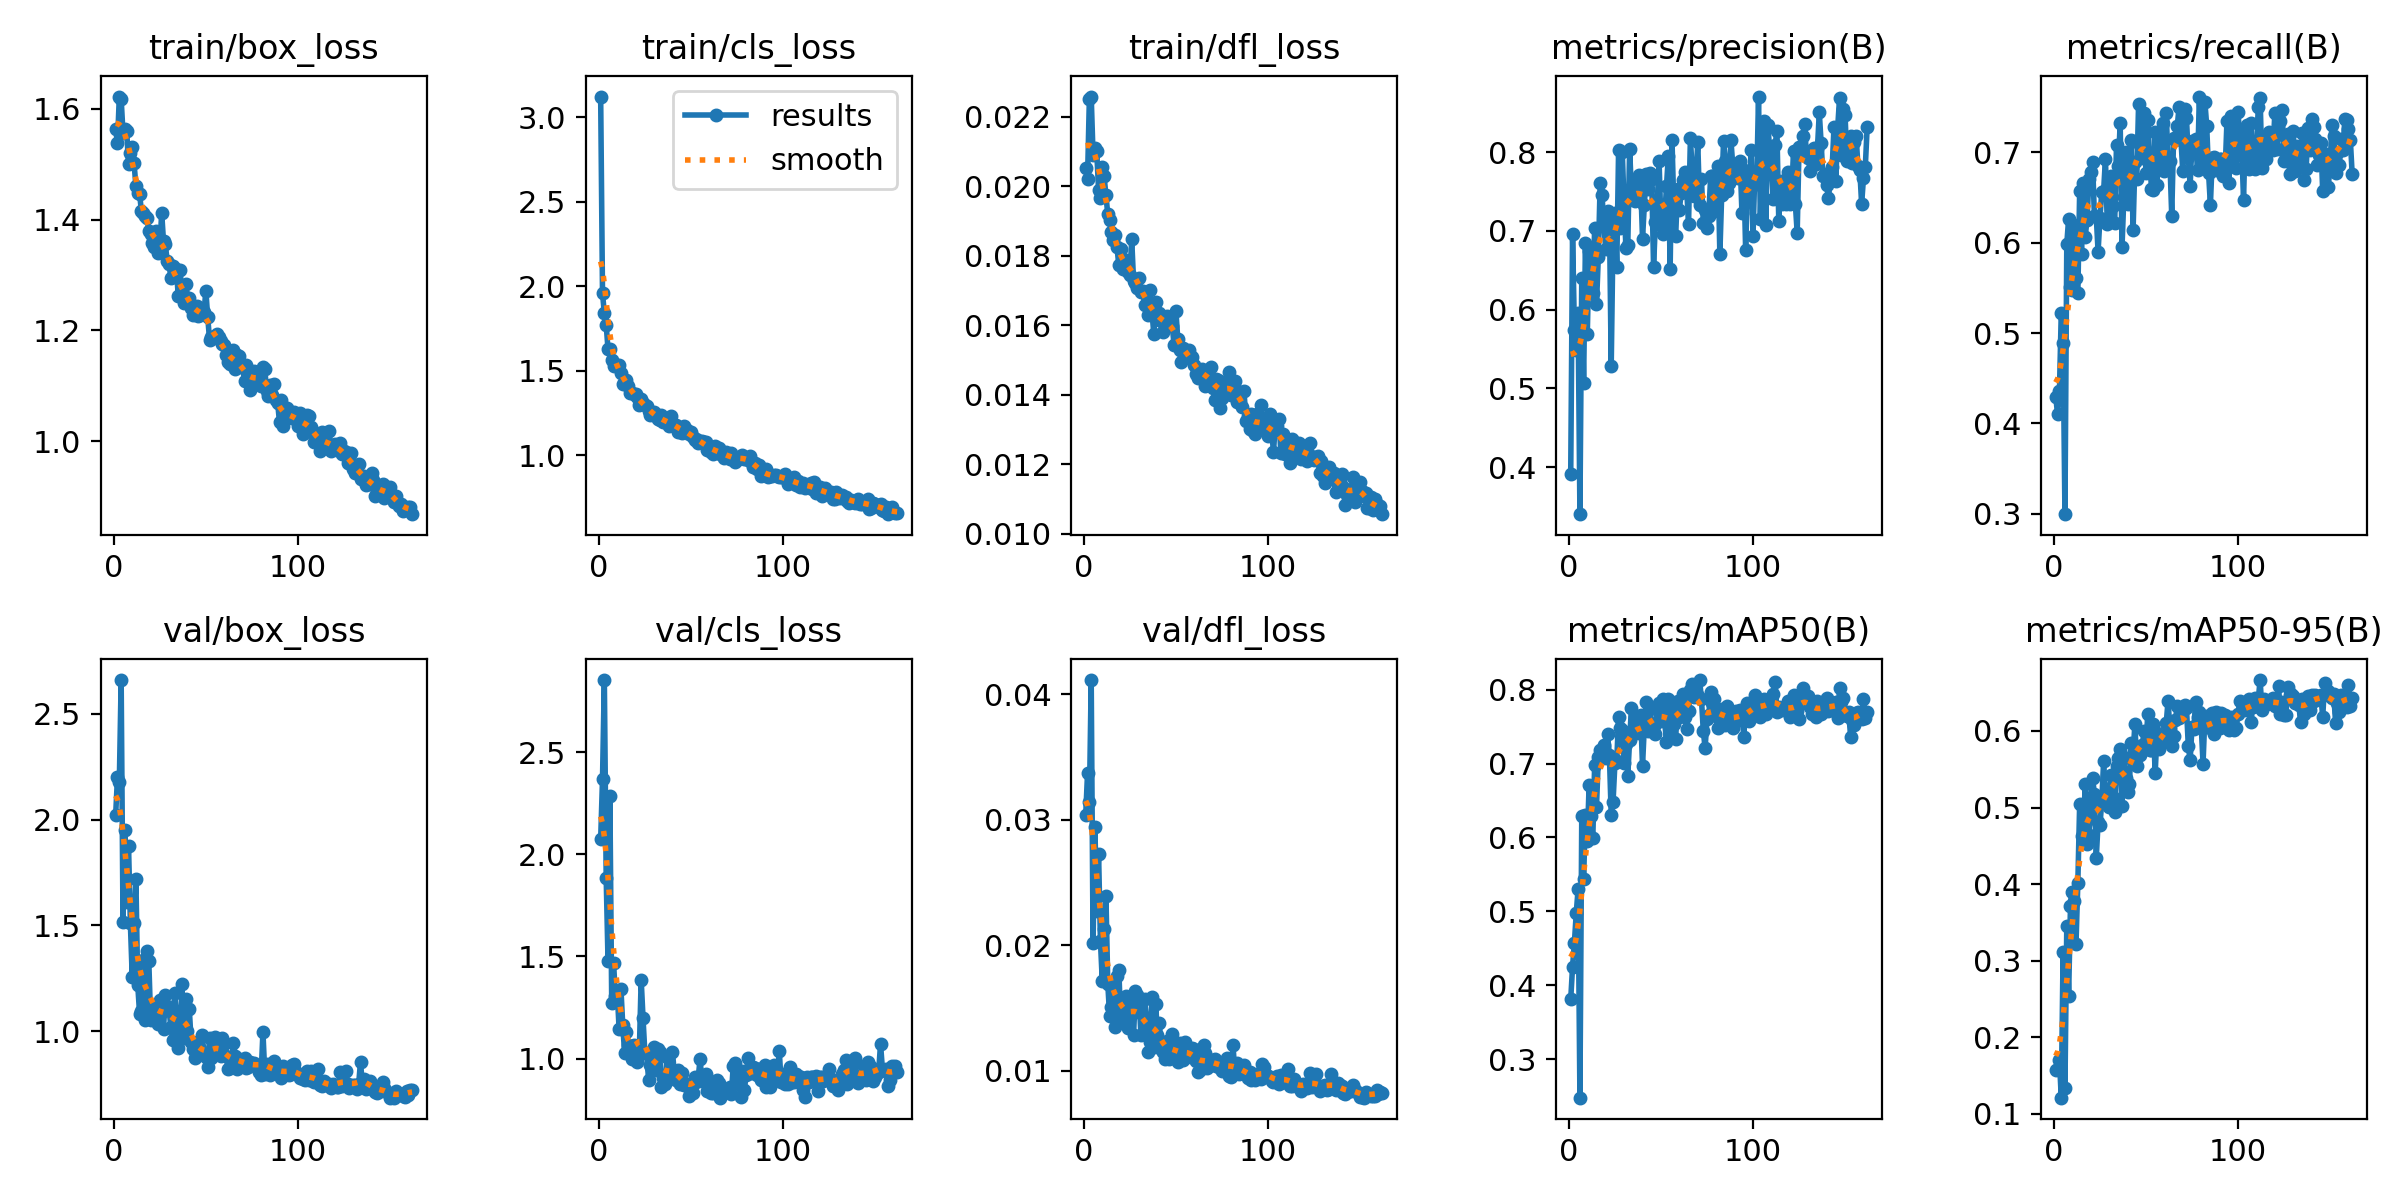

In [ ]:
import os
from IPython.display import display, Image

# Jalur folder hasil training di Google Drive
run_dir = '/content/drive/MyDrive/PI (PENULISAN ILMIAH SEMESTER 6) 2026/BEST MODEL YOLO26n-v3/v2_training'

print("--- MENAMPILKAN HASIL EVALUASI MODEL ---")

# 1. Menampilkan Confusion Matrix (Melihat akurasi deteksi per kelas penyakit)
confusion_matrix_path = os.path.join(run_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print("\n[1] Confusion Matrix:")
    display(Image(filename=confusion_matrix_path, width=600))

# 2. Menampilkan Grafik Progress Results (Melihat penurunan Loss dan kenaikan mAP per Epoch)
results_plot_path = os.path.join(run_dir, 'results.png')
if os.path.exists(results_plot_path):
    print("\n[2] Grafik Perkembangan Training (Loss & mAP):")
    display(Image(filename=results_plot_path, width=800))

#### BAGIAN 6: Uji Coba Deteksi (Inference) Dengan Grid 2×5 Dengan YOLO26m

--- MENJALANKAN DETEKSI GRID PADA 10 GAMBAR INFERENCE ---


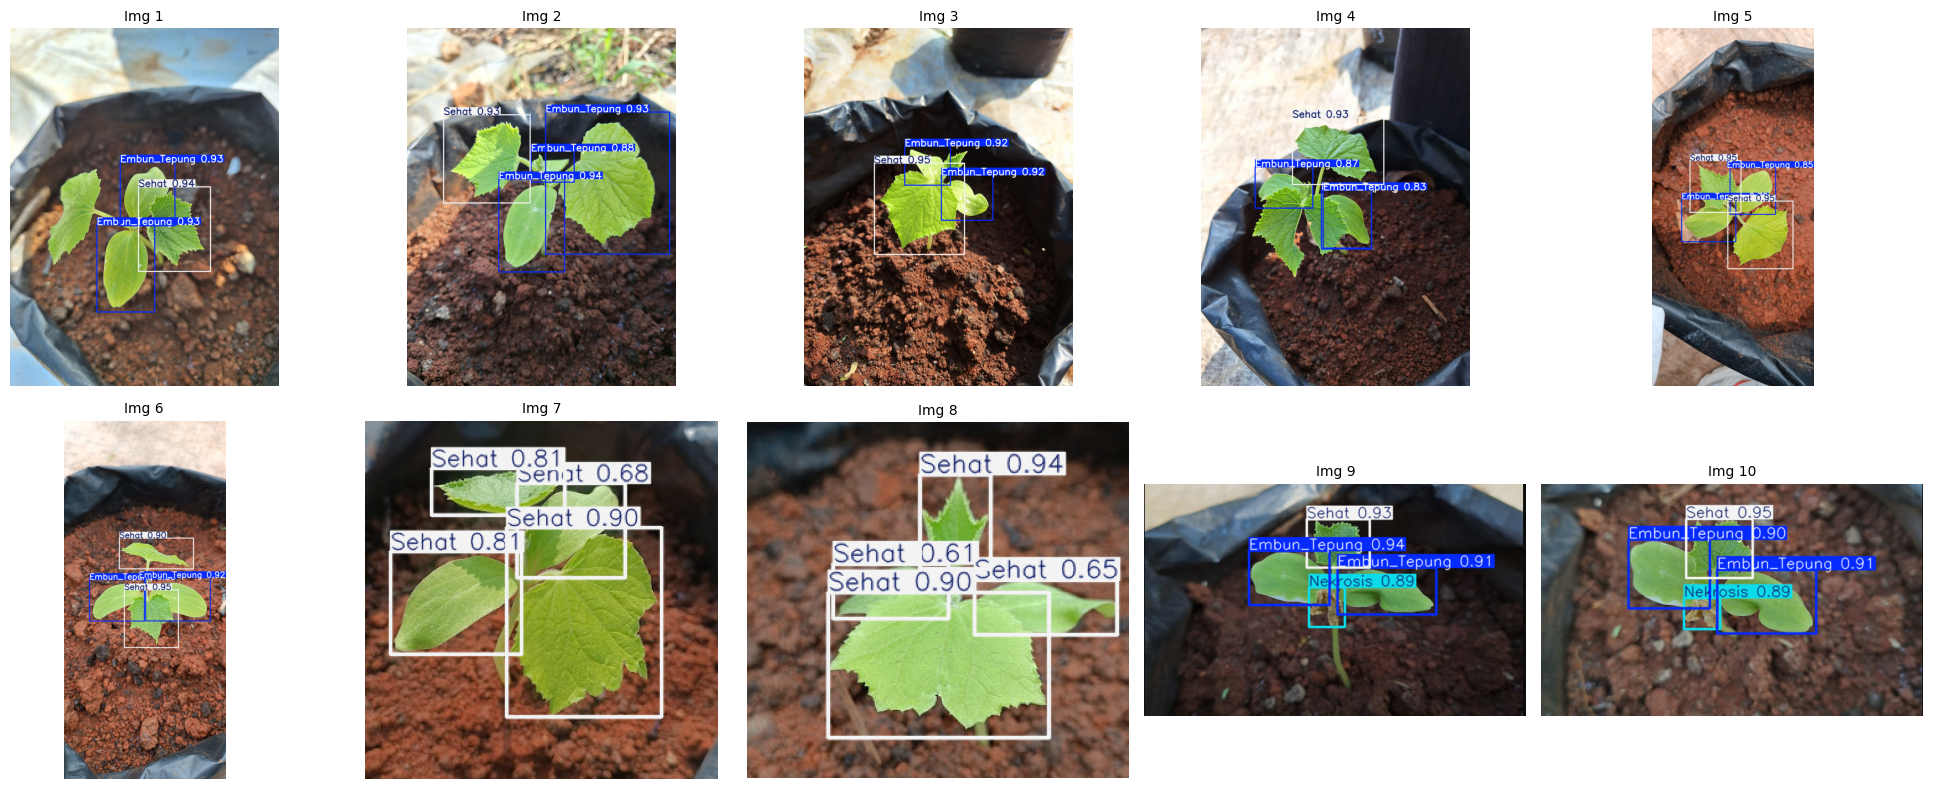

In [ ]:
import glob
import os
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO


# 1. Muat model yang tersimpan di GDrive
best_model_path = '/content/drive/MyDrive/PI (PENULISAN ILMIAH SEMESTER 6) 2026/BEST MODEL YOLO26n-v3/v2_training/weights/best.pt'
model_best = YOLO(best_model_path)

# 3. Ambil seluruh sampel gambar dari folder DATA INFERENCE di GDrive
inference_folder_path = '/content/drive/MyDrive/PI (PENULISAN ILMIAH SEMESTER 6) 2026/DATA INFERENCE/*.jpg'
test_images = glob.glob(inference_folder_path)

print(f"--- MENJALANKAN DETEKSI GRID PADA {len(test_images)} GAMBAR INFERENCE ---")

# 4. Setup Grid Plot disesuaikan untuk 10 gambar (2 baris x 5 kolom)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, img_path in enumerate(test_images):
    # Prediksi
    results = model_best.predict(source=img_path, conf=0.50, verbose=False)

    # Ambil hasil plot (gambar yang sudah ada bounding box)
    res_plotted = results[0].plot()

    # Konversi BGR ke RGB untuk matplotlib
    res_plotted = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    # Tampilkan di grid
    axes[i].imshow(res_plotted)
    axes[i].axis('off')
    axes[i].set_title(f"Img {i+1}", fontsize=10)

# Menghapus sumbu koordinat jika ada sisa grid ax yang kosong
for j in range(len(test_images), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()